# KONE Elevator Energy Analytics

This notebook analyzes elevator energy consumption, regenerative energy recovery, traffic volume, and usage patterns based on operational building data.

## Objectives
- Measure total energy consumption
- Quantify regenerative energy savings
- Analyze trip volume and hourly traffic
- Identify usage trends across time
- Generate insights for building efficiency

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
conn = sqlite3.connect("../data/kone_energy.db")

In [4]:
df = pd.read_sql("SELECT * FROM energy_readings", conn)
df.head()

,id,elevator_id,building_id,timestamp,kwh,trips,avg_load_pct,standby_kwh,regen_kwh
0,1,BLD-001-ELV-01,BLD-001,2025-12-18 13:00:00,0.6766,27,69.43,0.1308,0.1009
1,2,BLD-001-ELV-01,BLD-001,2025-12-18 14:00:00,0.5600,24,50.17,0.1037,0.0480
2,3,BLD-001-ELV-01,BLD-001,2025-12-18 15:00:00,0.7135,25,54.89,0.1492,0.0842
3,4,BLD-001-ELV-01,BLD-001,2025-12-18 16:00:00,0.4476,18,33.47,0.0621,0.0804
4,5,BLD-001-ELV-01,BLD-001,2025-12-18 17:00:00,1.0317,39,70.57,0.0794,0.2048


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43220 entries, 0 to 43219
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            43220 non-null  int64  
 1   elevator_id   43220 non-null  str    
 2   building_id   43220 non-null  str    
 3   timestamp     43220 non-null  str    
 4   kwh           43220 non-null  float64
 5   trips         43220 non-null  int64  
 6   avg_load_pct  43220 non-null  float64
 7   standby_kwh   43220 non-null  float64
 8   regen_kwh     43220 non-null  float64
dtypes: float64(4), int64(2), str(3)
memory usage: 3.0 MB


In [6]:
df.describe()

,id,kwh,trips,avg_load_pct,standby_kwh,regen_kwh
count,43220.000000,43220.000000,43220.000000,43220.000000,43220.000000,43220.000000
mean,21610.500000,0.412522,16.525868,38.135347,0.100233,0.051503
std,12476.683654,0.241992,16.050598,19.924547,0.028918,0.036428
min,1.000000,0.100000,0.000000,10.000000,0.050000,0.005100
25%,10805.750000,0.250900,3.000000,21.940000,0.075000,0.026400
50%,21610.500000,0.352800,12.000000,32.450000,0.100200,0.041900
75%,32415.250000,0.489125,25.000000,52.770000,0.125500,0.064700
max,43220.000000,1.646200,60.000000,85.000000,0.150000,0.299700


In [8]:
df.columns

Index(['id', 'elevator_id', 'building_id', 'timestamp', 'kwh', 'trips',
       'avg_load_pct', 'standby_kwh', 'regen_kwh'],
      dtype='str')

In [9]:
df.head()

,id,elevator_id,building_id,timestamp,kwh,trips,avg_load_pct,standby_kwh,regen_kwh
0,1,BLD-001-ELV-01,BLD-001,2025-12-18 13:00:00,0.6766,27,69.43,0.1308,0.1009
1,2,BLD-001-ELV-01,BLD-001,2025-12-18 14:00:00,0.5600,24,50.17,0.1037,0.0480
2,3,BLD-001-ELV-01,BLD-001,2025-12-18 15:00:00,0.7135,25,54.89,0.1492,0.0842
3,4,BLD-001-ELV-01,BLD-001,2025-12-18 16:00:00,0.4476,18,33.47,0.0621,0.0804
4,5,BLD-001-ELV-01,BLD-001,2025-12-18 17:00:00,1.0317,39,70.57,0.0794,0.2048


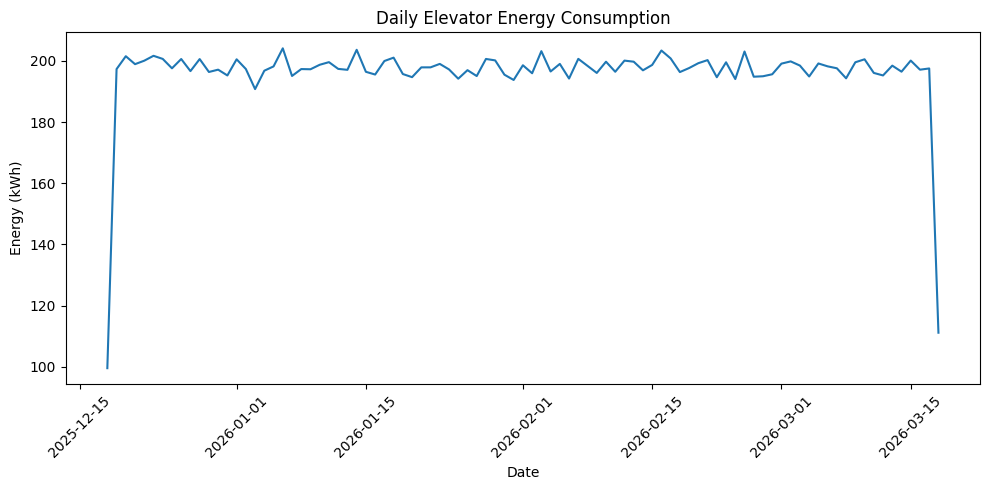

In [10]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

daily_energy = df.groupby(df["timestamp"].dt.date)["kwh"].sum()

plt.figure(figsize=(10, 5))
plt.plot(daily_energy.index, daily_energy.values)
plt.title("Daily Elevator Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

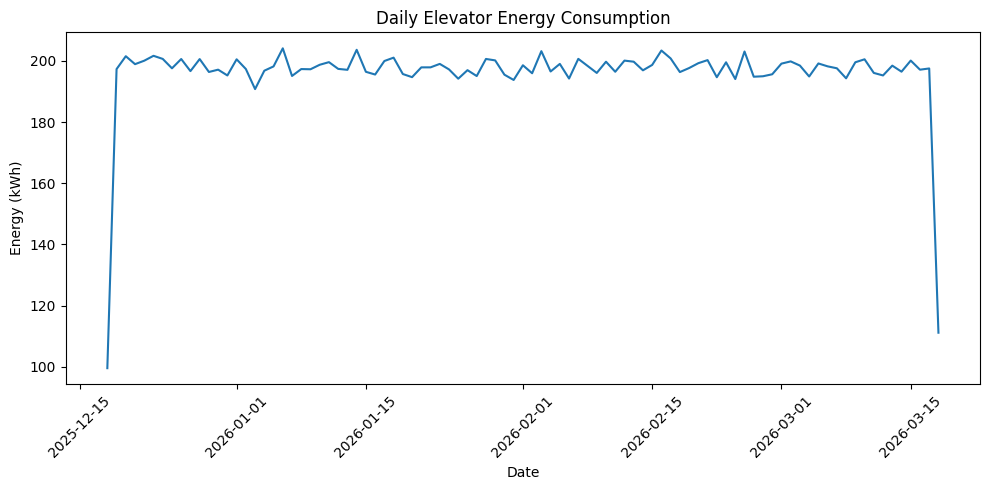

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(daily_energy.index, daily_energy.values)
plt.title("Daily Elevator Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../screenshots/daily_energy.png")
plt.show()